# 2107541 Machine Learning for Environmental Applications
## Lecture 3 : Classification (Logistic Regression & Support Vector Machine)
### Done By : 6730084521 Chatrphol Ovanonchai

## Step 1 : Import Dataset

In [29]:
## for vscode version
import pandas as pd
eutrophic_df = pd.read_csv("./eutrophication_dataset.csv")

## Step 2 : Define X (Feature) and y (Target)

In [31]:
## call dataframe
eutrophic_df

,Chlorophyll,Nitrate,Class
0,5,1.0,0
1,7,3.0,0
2,8,2.0,0
3,9,4.0,1
4,10,5.0,0
5,12,2.5,1
6,14,4.0,1
7,16,3.0,0
8,18,5.0,1
9,20,4.5,1


In [32]:
# Define the input features
X = eutrophic_df[ ['Chlorophyll','Nitrate'] ] ## DataFrame

# Define the target variable
y = eutrophic_df['Class'] # Series

## Step 3: Explore the data

In [33]:
# 3.1 descriptive statistics
eutrophic_df.describe()

,Chlorophyll,Nitrate,Class
count,10.000000,10.00000,10.000000
mean,11.900000,3.40000,0.500000
std,4.976612,1.32916,0.527046
min,5.000000,1.00000,0.000000
25%,8.250000,2.62500,0.000000
50%,11.000000,3.50000,0.500000
75%,15.500000,4.37500,1.000000
max,20.000000,5.00000,1.000000


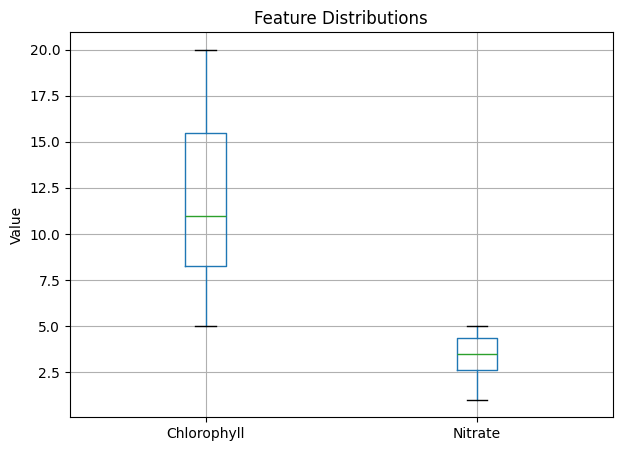

In [34]:
# 3.2 data distribution using box-whisker plot
import matplotlib.pyplot as plt

# Boxplot
X.boxplot(figsize=(7, 5)) ## Plot X (Feature) as boxplot
plt.title("Feature Distributions")
plt.ylabel("Value")
plt.show()

## Step 4: Standardize the Features

In [35]:
from sklearn.preprocessing import MinMaxScaler

# Create a scaler
scaler = MinMaxScaler() ## Scale to 1

# Scale the features
X_scaled = scaler.fit_transform(X)

In [36]:
# Create dataframe of X_scaled
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns) # copy column name from X (Feature)

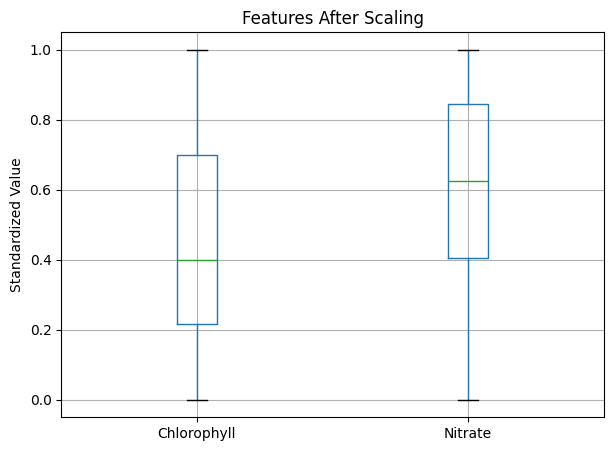

In [37]:
import matplotlib.pyplot as plt

# Boxplot
X_scaled_df.boxplot(figsize=(7, 5))
plt.title("Features After Scaling")
plt.ylabel("Standardized Value")
plt.show()

## Step 5: Train Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
# Create the Logistic Regression model
lr = LogisticRegression(C = 1)
# Train the model
lr.fit(X_scaled , y) # using .fit(feature , target)

LogisticRegression(C=1)

## Step 6: Predict a New Water Sample

In [39]:
# Create a new water sample
new_sample = pd.DataFrame({"Chlorophyll": [15], "Nitrate": [4.0]}) # DataFrame

# Scale the new sample
new_sample_scaled = scaler.transform(new_sample) ## train with transform (we dont have to use fit_transform)

# Predict the class
lr.predict(new_sample_scaled) # 0 = Non-Eutrophic

## Get the predicted probability
lr.predict_proba(new_sample_scaled) 

# returning array([[0.64962445, 0.35037555]])
## 0.64xx = likely to have 64.xx% to be class 0 (Non-Eutrophic)
## 0.35xx = likely to have 35.xx% to be class 1 (Eutrophic)

array([[0.4466356, 0.5533644]])

## Step 7: Try Different C

In [40]:
# Create Logistic Regression models with different C values
lr_small = LogisticRegression(C=0.1)
lr_large = LogisticRegression(C=100)

In [41]:
# Train the models
lr_small.fit(X_scaled , y)
lr_large.fit(X_scaled , y)

LogisticRegression(C=100)

In [42]:
print("C = 0.1:", lr_small.predict_proba(new_sample_scaled)) # 52% likely to be Non-Eutrophic (class 0)
print("C = 100:", lr_large.predict_proba(new_sample_scaled)) # 94% likely to be Non-Eutrophic (class 0)

C = 0.1: [[0.49285125 0.50714875]]
C = 100: [[0.26445562 0.73554438]]


## Extra : Logistic Regression

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


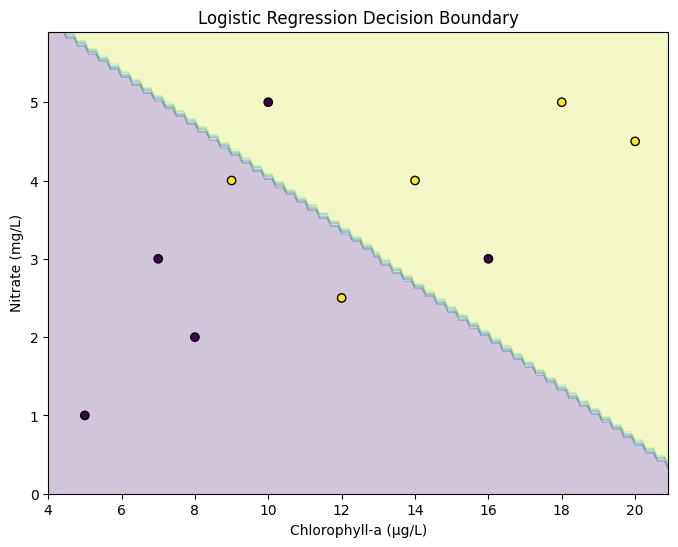

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create a grid of values
x_min, x_max = X["Chlorophyll"].min() - 1, X["Chlorophyll"].max() + 1
y_min, y_max = X["Nitrate"].min() - 1, X["Nitrate"].max() + 1
xx, yy = np.meshgrid(
 np.arange(x_min, x_max, 0.1),
 np.arange(y_min, y_max, 0.1) )

# Create grid data
grid = pd.DataFrame({
 "Chlorophyll": xx.ravel(),
 "Nitrate": yy.ravel()
})

# Scale the grid using the same scaler used for training
grid_scaled = scaler.transform(grid)

# Predict the class for every point in the grid
Z = lr.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)

# Plot the original observations
plt.scatter(
 X["Chlorophyll"],
 X["Nitrate"],
 c=y,
 edgecolor="black" )

plt.xlabel("Chlorophyll-a (µg/L)")
plt.ylabel("Nitrate (mg/L)")
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [44]:
from sklearn.svm import SVC
# Create a linear SVM model
svm_linear = SVC(kernel="linear", C=1 , gamma='scale') # Support Vector CLassifier
# Train the model
svm_linear.fit(X_scaled, y)

SVC(C=1, kernel='linear')

## Step 9: Predict the Same Water Sample 

In [45]:
# Predict the class
svm_linear.predict(new_sample_scaled) # Class 1 = Eutrophic 

# Get the SVM decision score
svm_linear.decision_function(new_sample_scaled) # 0.4914 > 0 (over decision boundary) -> Class 1 Eutrophic
## still close to decision boundary 

array([0.49144546])

## Step 10: Try Different Values of C

In [46]:
# Create SVM models with different C values
svm_c01 = SVC(kernel="linear", C=0.1 , gamma = "scale")
svm_c1 = SVC(kernel="linear", C=1, gamma = "scale")
svm_c100 = SVC(kernel="linear", C=100, gamma = "scale")

# Train the models
svm_c01.fit(X_scaled, y)
svm_c1.fit(X_scaled, y)
svm_c100.fit(X_scaled, y)

SVC(C=100, kernel='linear')

In [47]:
print("C = 0.1:", "Class " , svm_c01.predict(new_sample_scaled)[0] , "Having Decision Score " , svm_c01.decision_function(new_sample_scaled)[0]) 
    # 0.07 -> super close to decision boundary
    
print("C = 1:", "Class " , svm_c1.predict(new_sample_scaled)[0] , "Having Decision Score " , svm_c1.decision_function(new_sample_scaled)[0]) 
    # 0.49 -> close to decision boundary
    
print("C = 100:", "Class " , svm_c100.predict(new_sample_scaled)[0] , "Having Decision Score " , svm_c100.decision_function(new_sample_scaled)[0]) 
    # 1.25 -> far from decision boundary

C = 0.1: Class  1 Having Decision Score  0.07687500238418579
C = 1: Class  1 Having Decision Score  0.4914454634562355
C = 100: Class  1 Having Decision Score  1.2500764426229471


Note : `.predict()` gives "class" as result" but `.predict_proba()` gives probability of each class instead
> p.s. `svm` doesn't have `.predict_proba()` function

## Step 11: Compare with RBF SVM

In [48]:
# Create an RBF SVM model
svm_rbf = SVC(kernel="rbf", C=1 , gamma = "scale")

# Train the model
svm_rbf.fit(X_scaled, y)

SVC(C=1)

In [49]:
# Predict the new water sample
svm_rbf.predict(new_sample_scaled) ## Class 1 = Eutrophic

array([1])

In [50]:
print("Linear SVM:")
print(svm_linear.decision_function(new_sample_scaled)) 
print("RBF SVM:")
print(svm_rbf.decision_function(new_sample_scaled))

Linear SVM:
[0.49144546]
RBF SVM:
[0.89886555]


## Extra : Support Vector Machine Boundary & Margins

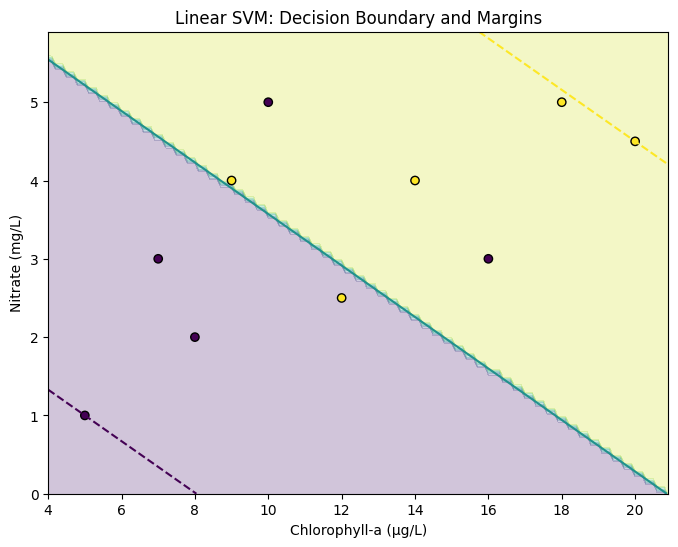

In [51]:
# Create a grid of values
x_min, x_max = X["Chlorophyll"].min() - 1, X["Chlorophyll"].max() + 1
y_min, y_max = X["Nitrate"].min() - 1, X["Nitrate"].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))

# Create grid data
grid = pd.DataFrame({
 "Chlorophyll": xx.ravel(),
 "Nitrate": yy.ravel()
})

# Scale the grid using the same scaler used for training
grid_scaled = scaler.transform(grid) 
    ## model trained from X_scaled , so using transform (learning min/max from old data , not new data)

# Predict the class for every point in the grid
Z = svm_linear.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Get the decision score for every point
decision_scores = svm_linear.decision_function(grid_scaled)
decision_scores = decision_scores.reshape(xx.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))
plt.contourf(
 xx,
 yy,
 Z,
 alpha=0.25)

# Plot margins and decision boundary
plt.contour(
 xx,
 yy,
 decision_scores,
 levels=[-1, 0, 1],
 linestyles=["--", "-", "--"] )

# Plot the original observations
plt.scatter(
 X["Chlorophyll"],
 X["Nitrate"],
 c=y,
 edgecolor="black" )

# Set Graph Attributes
plt.xlabel("Chlorophyll-a (µg/L)")
plt.ylabel("Nitrate (mg/L)")
plt.title("Linear SVM: Decision Boundary and Margins")
plt.show()

## Code for `C (Regularization)` in SVM Decision Boundary

In [52]:
## define function for plotting SVM Boundary
def plot_svm_boundary(ax, model, X, y, scaler, title):
    # Create a grid of values
    x_min = X["Chlorophyll"].min() - 1
    x_max = X["Chlorophyll"].max() + 1
    y_min = X["Nitrate"].min() - 1
    y_max = X["Nitrate"].max() + 1

    # Create grid data
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    grid = pd.DataFrame({
        "Chlorophyll": xx.ravel(),
        "Nitrate": yy.ravel()
    })

    # Scale the grid using the same scaler used for training
    grid_scaled = scaler.transform(grid)

    # Predict the class for every point in the grid
    Z = model.predict(grid_scaled).reshape(xx.shape) # Z = class
    scores = model.decision_function(grid_scaled).reshape(xx.shape)

    # Plot the decision regions
    ax.contourf(xx, yy, Z, alpha=0.25)

    # Plot margins and decision boundary
    ax.contour(
        xx,
        yy,
        scores,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        colors="black"
    )

    # Plot the original observations
    ax.scatter(
        X["Chlorophyll"],
        X["Nitrate"],
        c=y,
        edgecolor="black"
    )

    # Set Graph Attributes
    ax.set_xlabel("Chlorophyll-a (µg/L)")
    ax.set_ylabel("Nitrate (mg/L)")
    ax.set_title(title)

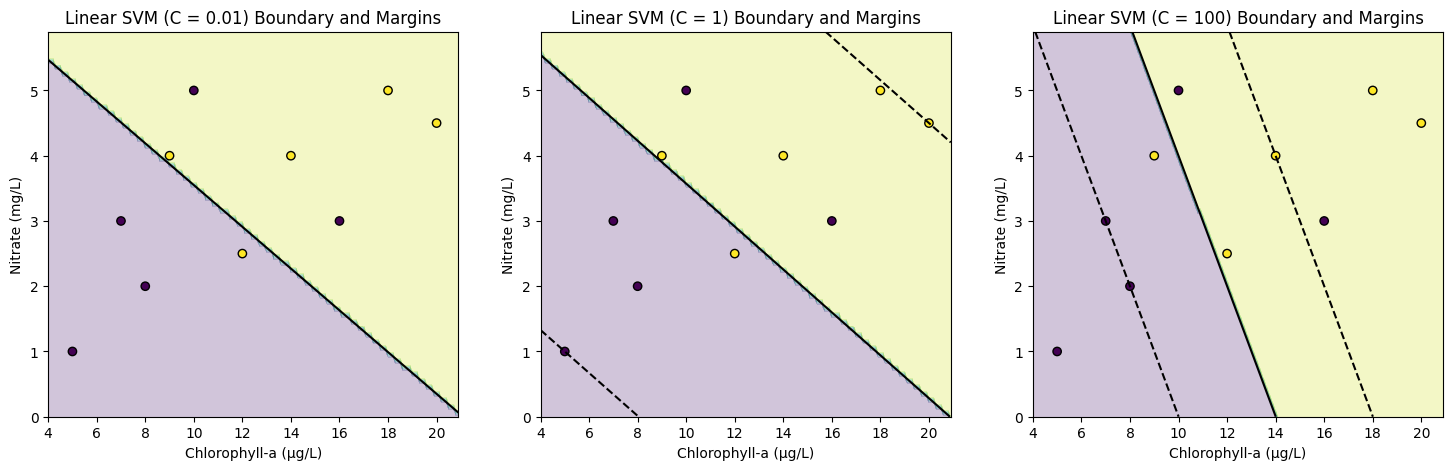

In [53]:
# define fig & axes
fig, axes = plt.subplots(1,3,figsize=(18, 5)) # 1 row 3 col , figsize = (18,5)

# plot each graph with different C
plot_svm_boundary(axes[0] , svm_c01 , X , y , scaler , title = "Linear SVM (C = 0.01) Boundary and Margins")
plot_svm_boundary(axes[1] , svm_c1 , X , y , scaler , title = "Linear SVM (C = 1) Boundary and Margins")
plot_svm_boundary(axes[2] , svm_c100 , X , y , scaler , title = "Linear SVM (C = 100) Boundary and Margins")

plt.show()

Note : Support Vectors = points which is in margin zone (including points at margin line too)
- C = 0.01 : Very Small Coefficient , Decision Score is super close to 0 , Margin is out of graph (width -> 2/0 -> inf)
- C = 100 : W_Chrolophyll >> W_Nitrate --> Model tries to be Hard Margin but still cannot due to data 

In [54]:
## See info of each Regularization in graph

models = {
    "C=0.01": svm_c01,
    "C=1": svm_c1,
    "C=100": svm_c100
}

for name, model in models.items():
    scores = model.decision_function(X_scaled)

    print(name)
    print("Weights:", model.coef_) # [weoght_class1 weoght_class2]
    print("Intercept:", model.intercept_)
    print("Accuracy:", model.score(X_scaled, y))
    print("Support vectors:", model.n_support_) # [n_class1 n_class2]
    print("Score range:", scores.min(), scores.max())
    print()
    
## But why accuracy = 0.7 --> let's try with another kernel trick (using Non-Linear SVM)

C=0.01
Weights: [[0.18 0.15]]
Intercept: [-0.155625]
Accuracy: 0.7
Support vectors: [5 5]
Score range: -0.15562499761581428 0.15562500238418575

C=1
Weights: [[1.16991153 0.94867259]]
Intercept: [-1.]
Accuracy: 0.7
Support vectors: [5 5]
Score range: -1.0 1.000000047683716

C=100
Weights: [[3.74929097 1.00131543]]
Intercept: [-2.00043745]
Accuracy: 0.7
Support vectors: [4 3]
Score range: -2.0004374452887976 2.625004528021311



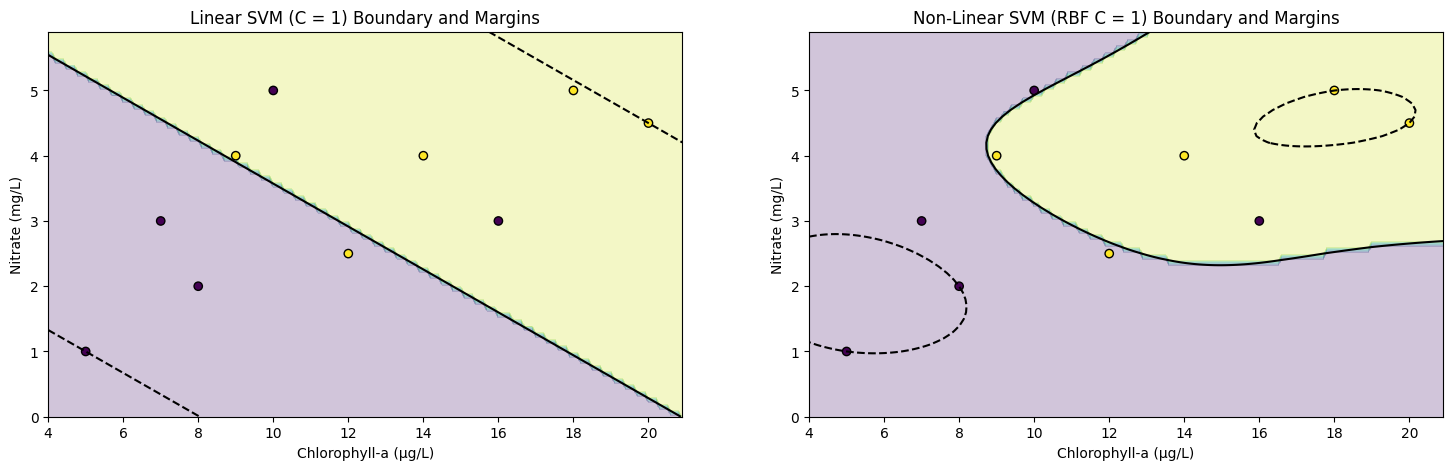

In [ ]:
## try using Non-Linear SVM VS Linear SVM

# define fig & axes
fig, axes = plt.subplots(1,2,figsize=(18, 5)) # 1 row 3 col , figsize = (18,5)

# plot each graph with different C
plot_svm_boundary(axes[0] , svm_c1 , X , y , scaler , title = "Linear SVM (C = 1) Boundary and Margins")
plot_svm_boundary(axes[1] , svm_rbf , X , y , scaler , title = "Non-Linear SVM (RBF C = 1) Boundary and Margins")

plt.show()